In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
dataset = pd.read_json('/content/drive/MyDrive/assignment_3_ai_tutors_dataset.json')
dataset

,conversation_id,conversation_history,tutor_responses
0,221-362eb11a-f190-42a6-b2a4-985fafdcfa9e,"Tutor: Hi, could you please provide a step-by-...","{'Sonnet': {'response': 'Great, you've correct..."
1,4642-e2ccfa55-280b-421c-9245-25ff56e3f33e,"Tutor: Hi, could you please provide a step-by-...",{'GPT4': {'response': 'You're doing great! But...
2,258053434,Tutor: You earn one point for your good beginn...,{'Sonnet': {'response': 'Let's double-check th...
3,429563766,Student: okey \n Tutor: Now we have the same d...,"{'Llama31405B': {'response': 'That's close, bu..."
4,2490-377791e8-3745-4eca-bea1-d07b6eb67afe,"Tutor: Hi, could you please provide a step-by-...",{'Gemini': {'response': 'It looks like you're ...
...,...,...,...
295,612-259f866a-0c6d-41c5-8a31-581518a44c4c,"Tutor: Hi, could you please provide a step-by-...",{'Llama31405B': {'response': 'It looks like yo...
296,790-86a2224d-29a2-4f8d-ad73-f5b5f6285f57,"Tutor: Hi, could you please provide a step-by-...",{'Gemini': {'response': 'It looks like you cor...
297,3882-b54fb9d9-a24c-4603-ba16-8eff77e8cdb1,"Tutor: Hi, could you please provide a step-by-...",{'Mistral': {'response': 'It looks like there ...
298,405563829_1,Tutor: We can compare the ratios more easily i...,{'Novice': {'response': 'That was a good try! ...


In [ ]:
df = dataset.copy()

In [ ]:
# Define all tutor names
all_tutors = ['Llama318B','Llama31405B', 'Phi3', 'Expert', 'Gemini', 'Novice', 'Mistral', 'GPT4', 'Sonnet']

# Create new DataFrame with desired structure
new_df = pd.DataFrame(columns=[
    'conversation_id', 'conversation_history', 'tutor_name', 'response',
    'annotation_Mistake_Identification', 'annotation_Mistake_Location',
    'annotation_Providing_Guidance', 'annotation_Actionability'
])

# Populate the DataFrame
for index, row in df.iterrows():
    conversation_id = row['conversation_id']
    conversation_history = row['conversation_history']

    try:
        tutor_responses = row['tutor_responses']

        # Iterate over all tutors, ensuring all are included
        for tutor_name in all_tutors:
            response_data = tutor_responses.get(tutor_name)  # Get data for current tutor


            if response_data is not None:  # Check if tutor data exists
                response = response_data.get('response', np.nan)  # Use np.nan for missing response
                annotation = response_data.get('annotation', {})
            else:
                response = np.nan
                annotation = {}

            new_row = {
                'conversation_id': conversation_id,
                'conversation_history': conversation_history,
                'tutor_name': tutor_name,
                'response': response,
                'annotation_Mistake_Identification': annotation.get('Mistake_Identification', np.nan),
                'annotation_Mistake_Location': annotation.get('Mistake_Location', np.nan),
                'annotation_Providing_Guidance': annotation.get('Providing_Guidance', np.nan),
                'annotation_Actionability': annotation.get('Actionability', np.nan)
            }
            new_df = pd.concat([new_df, pd.DataFrame([new_row])], ignore_index=True)

    except (KeyError, TypeError):
        print(f"Skipping row {index} due to missing or invalid data.")

df=new_df.copy()


In [ ]:
df.head(5)

,conversation_id,conversation_history,tutor_name,response,annotation_Mistake_Identification,annotation_Mistake_Location,annotation_Providing_Guidance,annotation_Actionability
0,221-362eb11a-f190-42a6-b2a4-985fafdcfa9e,"Tutor: Hi, could you please provide a step-by-...",Llama318B,Now that we know the cost of 1 pound of meat i...,Yes,To some extent,To some extent,To some extent
1,221-362eb11a-f190-42a6-b2a4-985fafdcfa9e,"Tutor: Hi, could you please provide a step-by-...",Llama31405B,"You're close, but I notice that you calculated...",Yes,Yes,Yes,Yes
2,221-362eb11a-f190-42a6-b2a4-985fafdcfa9e,"Tutor: Hi, could you please provide a step-by-...",Phi3,"To find the area of a rectangle, multiply its ...",No,No,To some extent,No
3,221-362eb11a-f190-42a6-b2a4-985fafdcfa9e,"Tutor: Hi, could you please provide a step-by-...",Expert,"And if there are 5 sandwiches, what is the mea...",Yes,Yes,Yes,Yes
4,221-362eb11a-f190-42a6-b2a4-985fafdcfa9e,"Tutor: Hi, could you please provide a step-by-...",Gemini,You're absolutely right about the cost of meat...,Yes,To some extent,To some extent,To some extent


In [ ]:
df.columns

Index(['conversation_id', 'conversation_history', 'tutor_name', 'response',
       'annotation_Mistake_Identification', 'annotation_Mistake_Location',
       'annotation_Providing_Guidance', 'annotation_Actionability'],
      dtype='object')

## EDA

tutor_name
Expert           0
GPT4             0
Gemini           0
Llama31405B      0
Llama318B        0
Mistral          0
Novice         224
Phi3             0
Sonnet           0
Name: response, dtype: int64


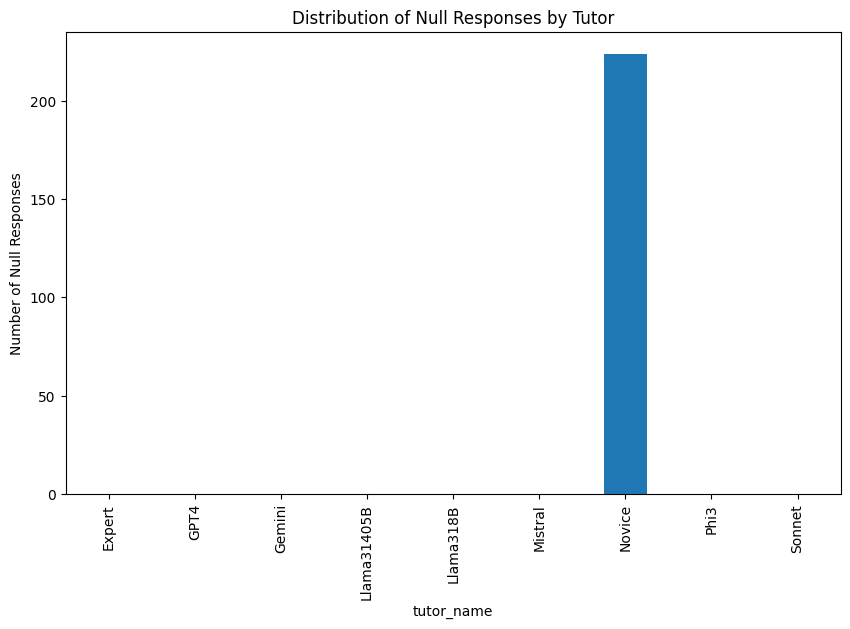

In [ ]:
null_responses_by_tutor = df.groupby('tutor_name')['response'].apply(lambda x: x.isnull().sum())
print(null_responses_by_tutor)
null_responses_by_tutor.plot(kind='bar', figsize=(10, 6))
plt.title('Distribution of Null Responses by Tutor')
plt.ylabel('Number of Null Responses')
plt.show()

annotation_Mistake_Identification   No  To some extent  Yes
tutor_name                                                 
Expert                              18              57  225
GPT4                                16               2  282
Gemini                              29              14  257
Llama31405B                          9               6  285
Llama318B                           36              21  243
Mistral                             12              18  270
Novice                              13              29   34
Phi3                               214               7   79
Sonnet                              23              20  257


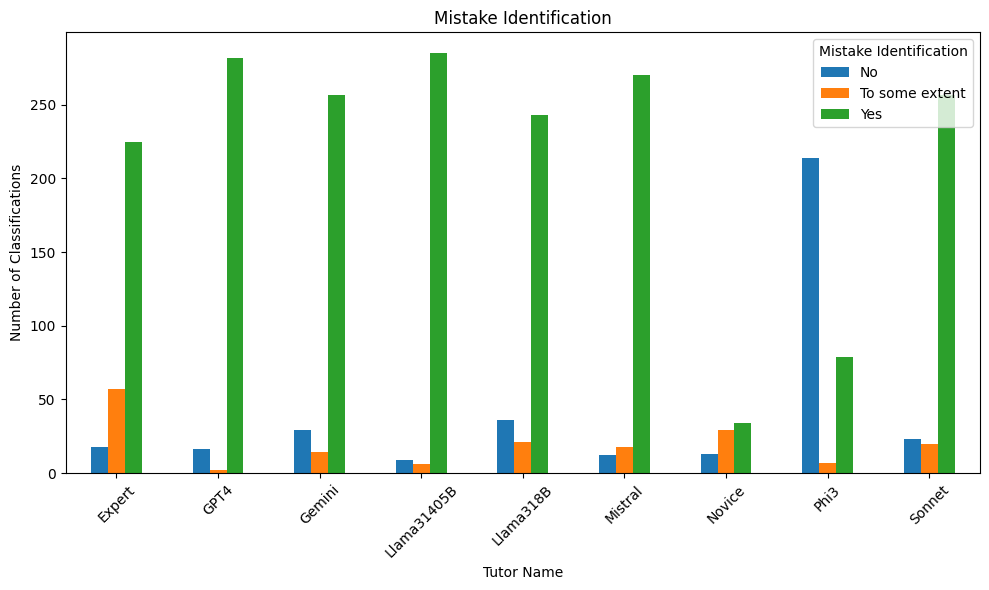

In [ ]:
# Calculate the classification distribution for each tutor (mistake identification)

classification_distribution = df.groupby('tutor_name')['annotation_Mistake_Identification'].value_counts().unstack(fill_value=0)


print(classification_distribution)
classification_distribution.plot(kind='bar', figsize=(10, 6))
plt.title('Mistake Identification')
plt.ylabel('Number of Classifications')
plt.xlabel('Tutor Name')
plt.xticks(rotation=45)
plt.legend(title='Mistake Identification')
plt.tight_layout()
plt.show()

annotation_Mistake_Location   No  To some extent  Yes
tutor_name                                           
Expert                        58              45  197
GPT4                          37              13  250
Gemini                        93              31  176
Llama31405B                   22              26  252
Llama318B                    108              31  161
Mistral                       52              35  213
Novice                        60               2   14
Phi3                         223               4   73
Sonnet                        60              33  207


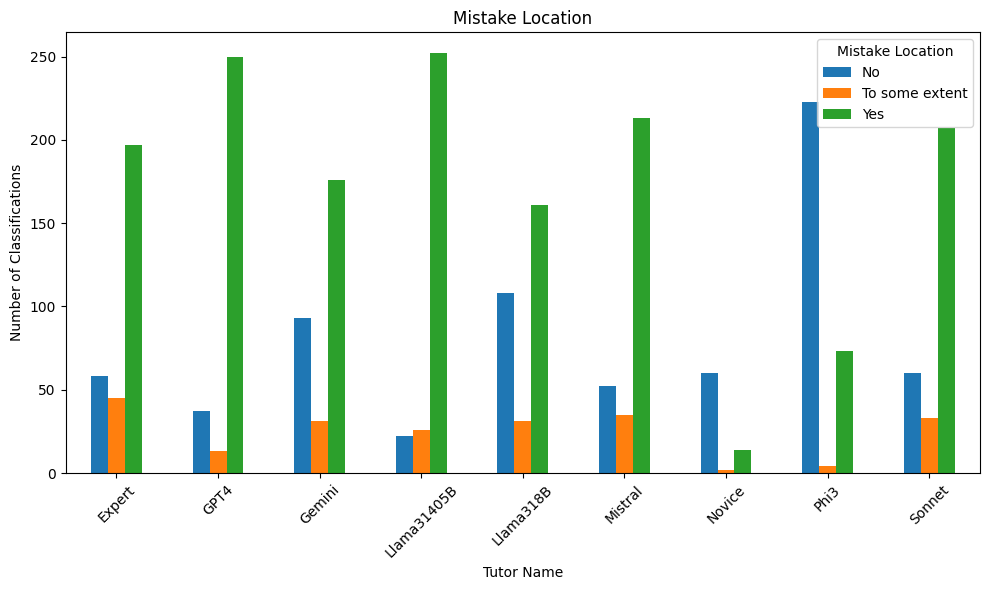

In [ ]:
# Calculate the classification distribution for each tutor (Mistake Location)

classification_distribution = df.groupby('tutor_name')['annotation_Mistake_Location'].value_counts().unstack(fill_value=0)
print(classification_distribution)

classification_distribution.plot(kind='bar', figsize=(10, 6))
plt.title('Mistake Location')
plt.ylabel('Number of Classifications')
plt.xlabel('Tutor Name')
plt.xticks(rotation=45)
plt.legend(title='Mistake Location')
plt.tight_layout()
plt.show()

annotation_Providing_Guidance   No  To some extent  Yes
tutor_name                                             
Expert                          47              48  205
GPT4                            41              31  228
Gemini                          47              85  168
Llama31405B                     16              46  238
Llama318B                       65             101  134
Mistral                         47              64  189
Novice                          62               4   10
Phi3                           189              60   51
Sonnet                          52              64  184


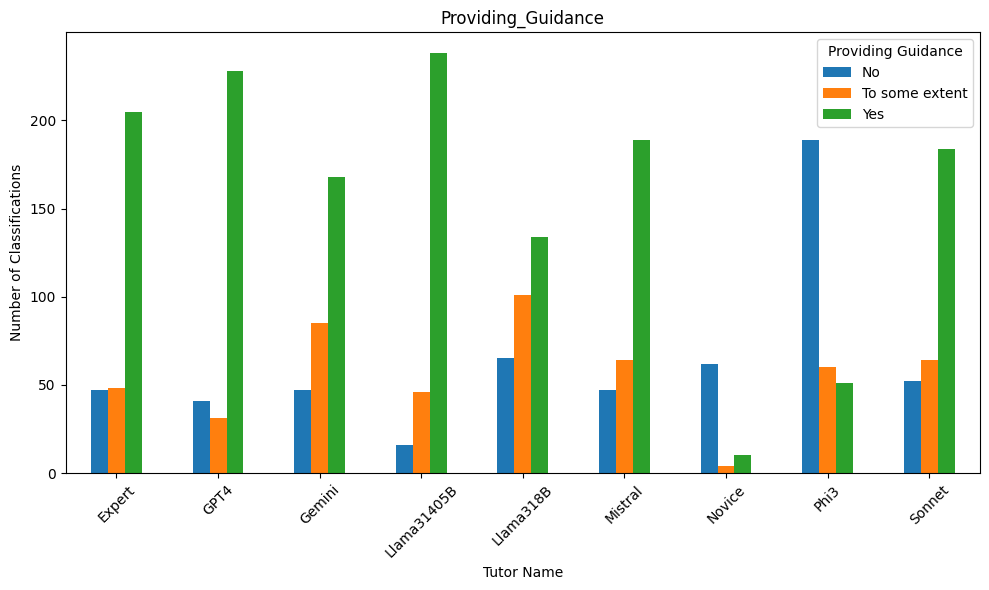

In [ ]:
# Calculate the classification distribution for each tutor (Mistake Location)

classification_distribution = df.groupby('tutor_name')['annotation_Providing_Guidance'].value_counts().unstack(fill_value=0)
print(classification_distribution)

classification_distribution.plot(kind='bar', figsize=(10, 6))
plt.title('Providing_Guidance')
plt.ylabel('Number of Classifications')
plt.xlabel('Tutor Name')
plt.xticks(rotation=45)
plt.legend(title='Providing Guidance')
plt.tight_layout()
plt.show()

annotation_Actionability   No  To some extent  Yes
tutor_name                                        
Expert                     20              39  241
GPT4                      149              13  138
Gemini                     64              67  169
Llama31405B                44              30  226
Llama318B                 114              61  125
Mistral                    48              48  204
Novice                     59              14    3
Phi3                      257              11   32
Sonnet                     42              86  172


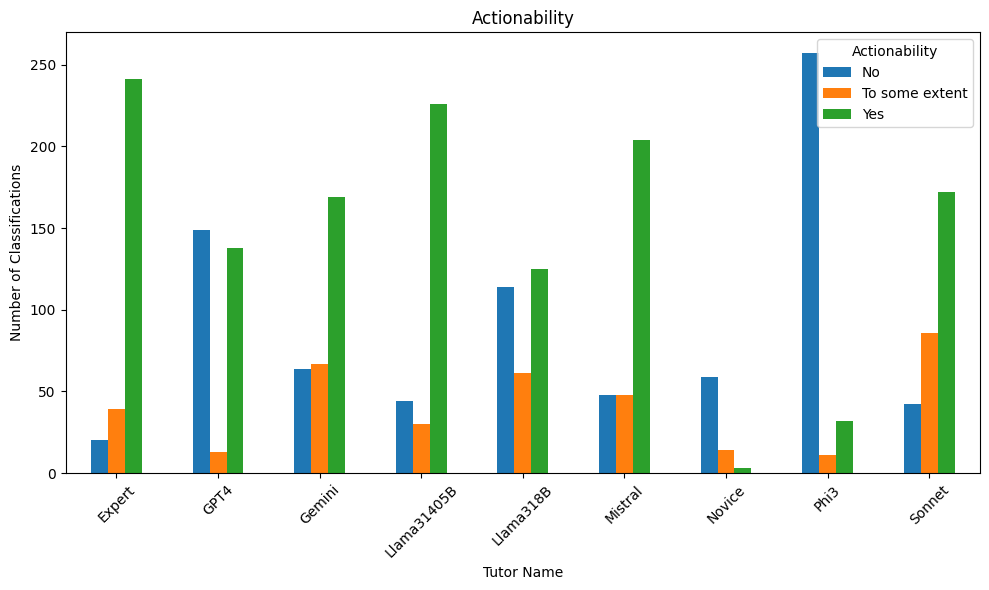

In [ ]:
# Calculate the classification distribution for each tutor (Actionability)

classification_distribution = df.groupby('tutor_name')['annotation_Actionability'].value_counts().unstack(fill_value=0)
print(classification_distribution)

classification_distribution.plot(kind='bar', figsize=(10, 6))
plt.title('Actionability')
plt.ylabel('Number of Classifications')
plt.xlabel('Tutor Name')
plt.xticks(rotation=45)
plt.legend(title='Actionability')
plt.tight_layout()
plt.show()

              Yes  To some extent   No  Total      Yes %
Llama31405B  1001             108   91   1200  83.416667
GPT4          898              59  243   1200  74.833333
Mistral       876             165  159   1200  73.000000
Expert        868             189  143   1200  72.333333
Sonnet        820             203  177   1200  68.333333
Gemini        770             197  233   1200  64.166667
Llama318B     663             214  323   1200  55.250000
Novice         61              49  194    304  20.065789
Phi3          235              82  883   1200  19.583333


<Figure size 1000x600 with 0 Axes>

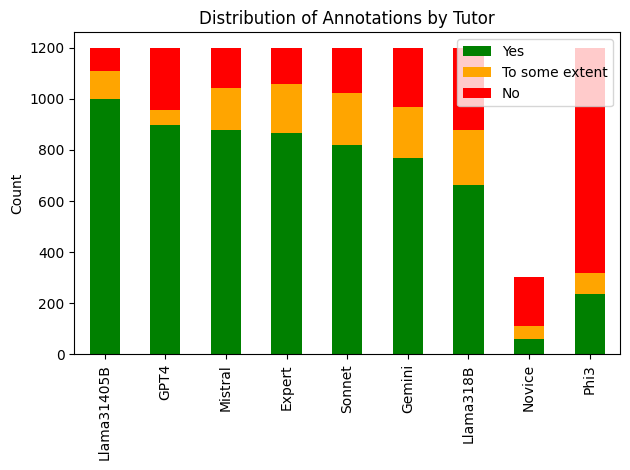

In [ ]:
# Calculate average response length for each tutor
average_response_length_by_tutor = df.groupby('tutor_name')['response'].apply(lambda x: x.str.len().mean())

average_response_length_by_tutor

annotation_cols = [
    'annotation_Mistake_Identification',
    'annotation_Mistake_Location',
    'annotation_Providing_Guidance',
    'annotation_Actionability'
]
# Count the occurrence of each annotation value for each tutor
results = {}
for tutor in df['tutor_name'].unique():
    tutor_data = df[df['tutor_name'] == tutor]


    yes_count = 0
    some_extent_count = 0
    no_count = 0

    for col in annotation_cols:
        yes_count += (tutor_data[col] == 'Yes').sum()
        some_extent_count += (tutor_data[col] == 'To some extent').sum()
        no_count += (tutor_data[col] == 'No').sum()

    results[tutor] = {
        'Yes': yes_count,
        'To some extent': some_extent_count,
        'No': no_count
    }

results_df = pd.DataFrame(results).T
results_df['Total'] = results_df.sum(axis=1)
results_df['Yes %'] = (results_df['Yes'] / results_df['Total']) * 100

# Sort by 'Yes %' in descending order
results_df = results_df.sort_values('Yes %', ascending=False)
print(results_df)

plt.figure(figsize=(10, 6))
results_df[['Yes', 'To some extent', 'No']].plot(
    kind='bar',
    stacked=True,
    color=['green', 'orange', 'red']
)
plt.title('Distribution of Annotations by Tutor')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
#Relation between mistake identification and mistake location


cross_tab = pd.crosstab(df['annotation_Mistake_Identification'], df['annotation_Mistake_Location'], margins=True, margins_name="Total")
cross_tab_percentage = cross_tab.div(cross_tab["Total"], axis=0) * 100

print("Cross-tabulation with Total Count:")
print(cross_tab)
print("\nCross-tabulation with Percentages:")
print(cross_tab_percentage)

Cross-tabulation with Total Count:
annotation_Mistake_Location         No  To some extent   Yes  Total
annotation_Mistake_Identification                                  
No                                 366               3     1    370
To some extent                     106              52    16    174
Yes                                241             165  1526   1932
Total                              713             220  1543   2476

Cross-tabulation with Percentages:
annotation_Mistake_Location               No  To some extent        Yes  Total
annotation_Mistake_Identification                                             
No                                 98.918919        0.810811   0.270270  100.0
To some extent                     60.919540       29.885057   9.195402  100.0
Yes                                12.474120        8.540373  78.985507  100.0
Total                              28.796446        8.885299  62.318255  100.0


There is a relation between mistake location and mistake identification.

When Mistake identification = no , 98.89% Mistake Location = no
When Mistake identification = yes , 77.47% Mistake Location = yes

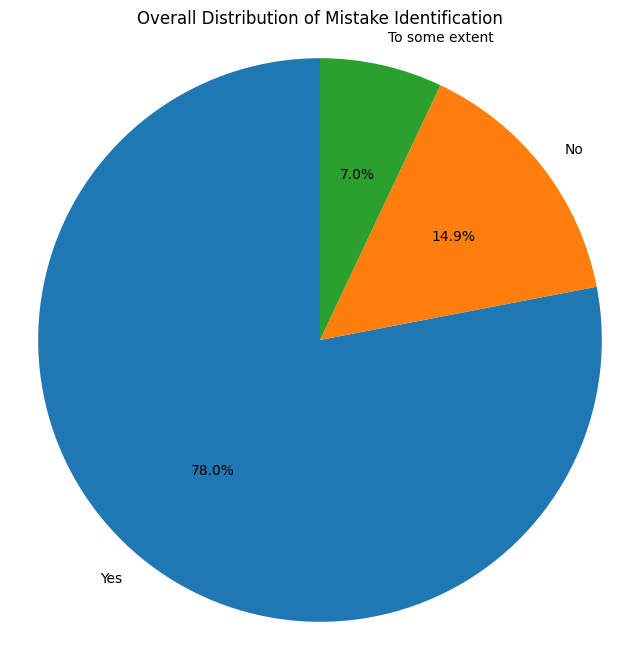

In [ ]:
# PIE CHART FOR OVERALL DISTRIBUTION OF THE 3 CLASSES FOR MISTAKE IDENTIFICATION

import matplotlib.pyplot as plt



# Calculate the overall distribution of mistake identification across all tutors
overall_mistake_identification = df['annotation_Mistake_Identification'].value_counts(normalize=True) * 100

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(overall_mistake_identification, labels=overall_mistake_identification.index, autopct='%1.1f%%', startangle=90)
plt.title('Overall Distribution of Mistake Identification')
plt.axis('equal')
plt.show()


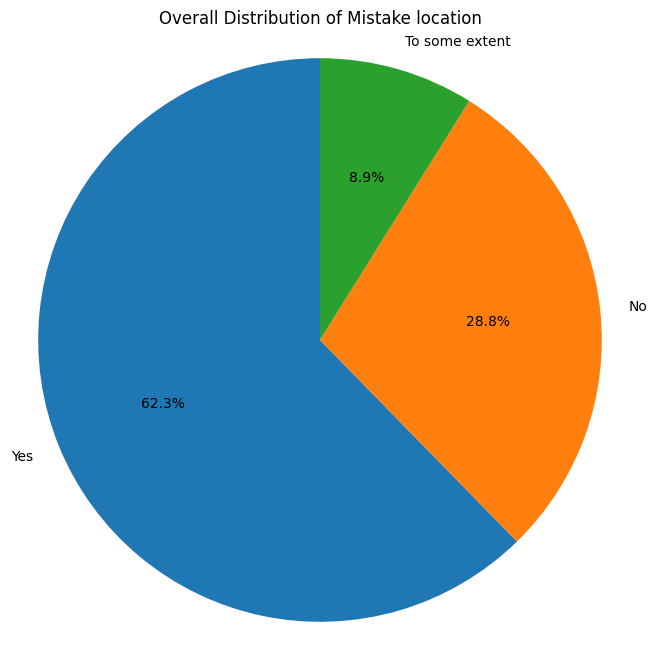

In [ ]:
# PIE CHART FOR OVERALL DISTRIBUTION OF THE 3 CLASSES FOR MISTAKE LOCATION


# Calculate the overall distribution of mistake LOCATION across all tutors
overall_mistake_location = df['annotation_Mistake_Location'].value_counts(normalize=True) * 100

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(overall_mistake_location, labels=overall_mistake_location.index, autopct='%1.1f%%', startangle=90)
plt.title('Overall Distribution of Mistake location')
plt.axis('equal')
plt.show()





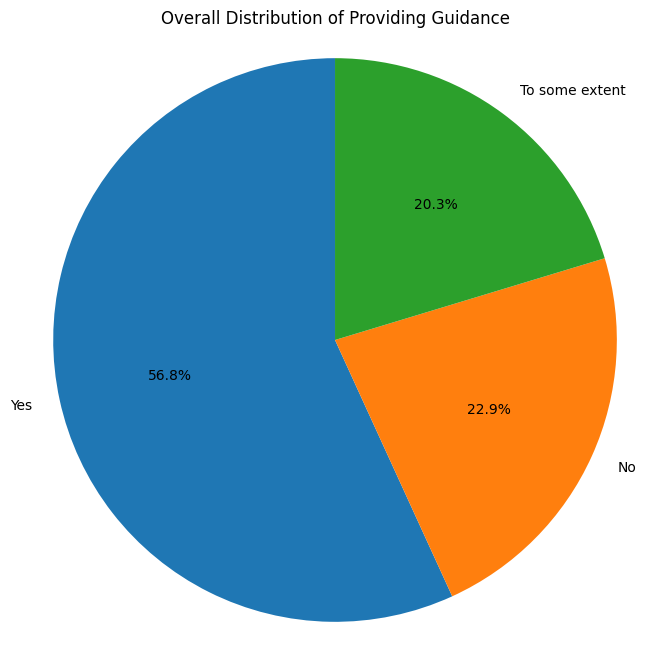

In [ ]:
overall_providing_guidance = df['annotation_Providing_Guidance'].value_counts(normalize=True) * 100

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(overall_providing_guidance, labels=overall_providing_guidance.index, autopct='%1.1f%%', startangle=90)
plt.title('Overall Distribution of Providing Guidance')
plt.axis('equal')
plt.show()

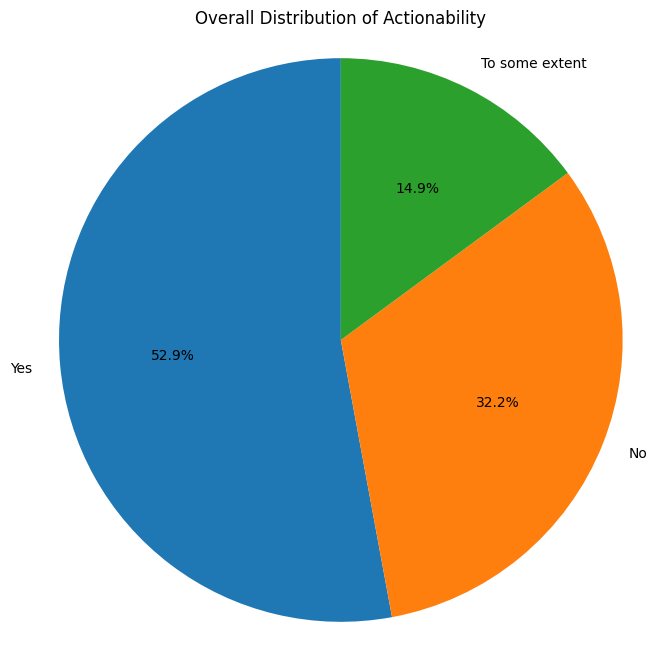

In [ ]:
overall_providing_actionability = df['annotation_Actionability'].value_counts(normalize=True) * 100

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(overall_providing_actionability, labels=overall_providing_actionability.index, autopct='%1.1f%%', startangle=90)
plt.title('Overall Distribution of Actionability')
plt.axis('equal')
plt.show()

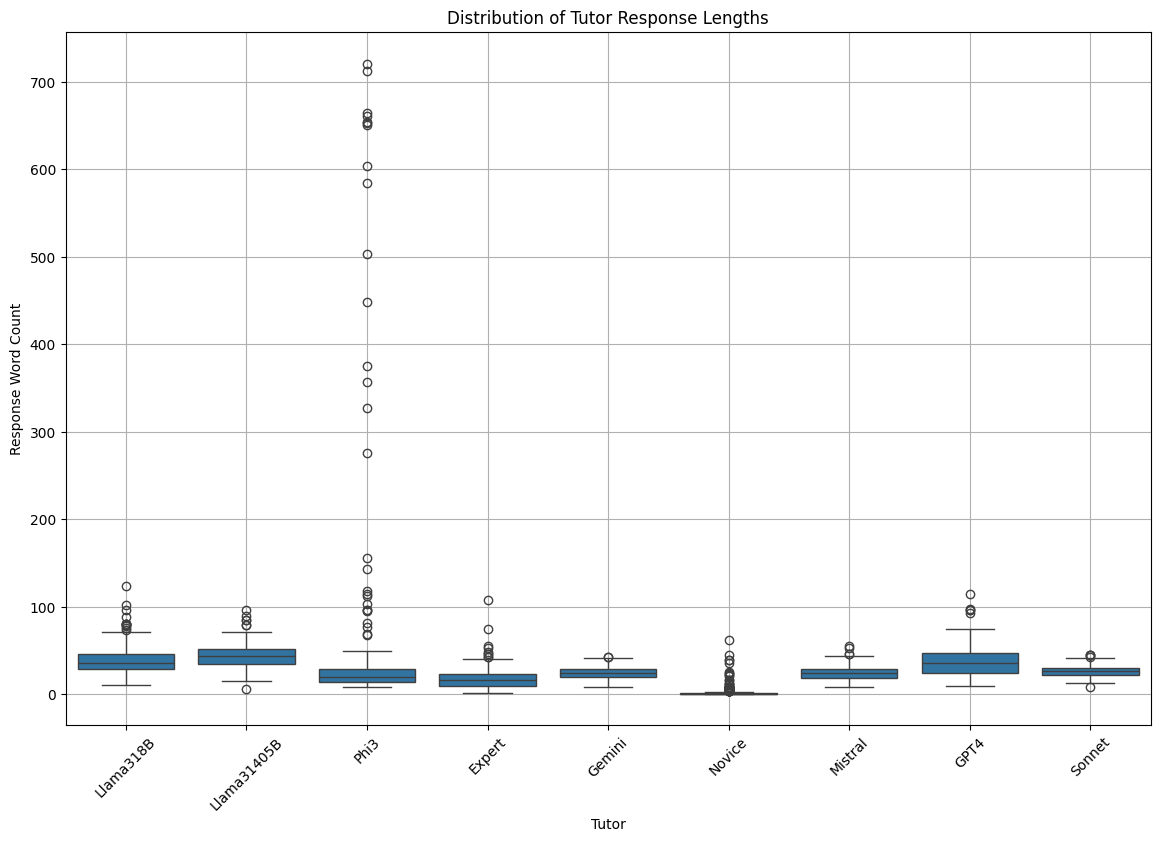

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df['response_word_count'] = df['response'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(14, 9))
sns.boxplot(x='tutor_name', y='response_word_count', data=df)
plt.xlabel('Tutor')
plt.ylabel('Response Word Count')
plt.title('Distribution of Tutor Response Lengths')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


<ipython-input-37-b9524f561f57>:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (comparison_df['Yes'][i], comparison_df['Average Response Length'][i]))


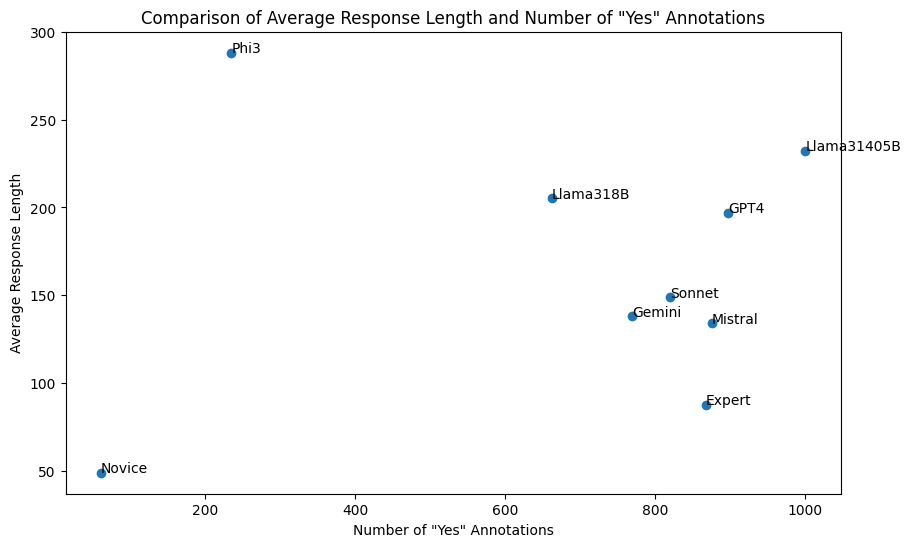

In [ ]:
# comparison of average response length and the total number of yes values for the 4 annotation for each tutor

# Merge the two dataframes
comparison_df = pd.merge(results_df, average_response_length_by_tutor, left_index=True, right_index=True)
comparison_df = comparison_df.rename(columns={'response': 'Average Response Length'})

# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(comparison_df['Yes'], comparison_df['Average Response Length'])
plt.xlabel('Number of "Yes" Annotations')
plt.ylabel('Average Response Length')
plt.title('Comparison of Average Response Length and Number of "Yes" Annotations')
for i, txt in enumerate(comparison_df.index):
    plt.annotate(txt, (comparison_df['Yes'][i], comparison_df['Average Response Length'][i]))
plt.show()


<ipython-input-38-fe5b6c1573b3>:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (comparison_df['No'][i], comparison_df['Average Response Length'][i]))


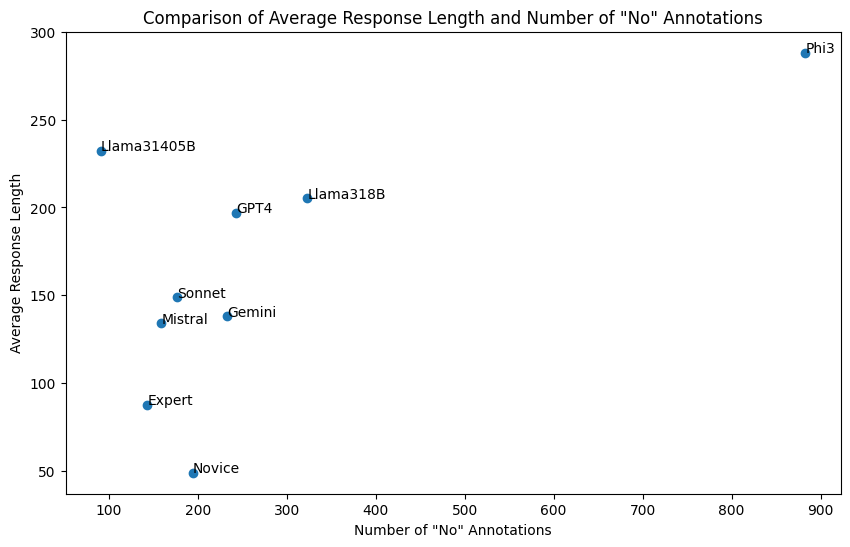

In [ ]:
# comparison of average response length and the total number no value for the 4 annotation for each tutor

plt.figure(figsize=(10, 6))
plt.scatter(comparison_df['No'], comparison_df['Average Response Length'])
plt.xlabel('Number of "No" Annotations')
plt.ylabel('Average Response Length')
plt.title('Comparison of Average Response Length and Number of "No" Annotations')
for i, txt in enumerate(comparison_df.index):
    plt.annotate(txt, (comparison_df['No'][i], comparison_df['Average Response Length'][i]))
plt.show()

<ipython-input-39-cd7cbaecbae1>:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (comparison_df['To some extent'][i], comparison_df['Average Response Length'][i]))


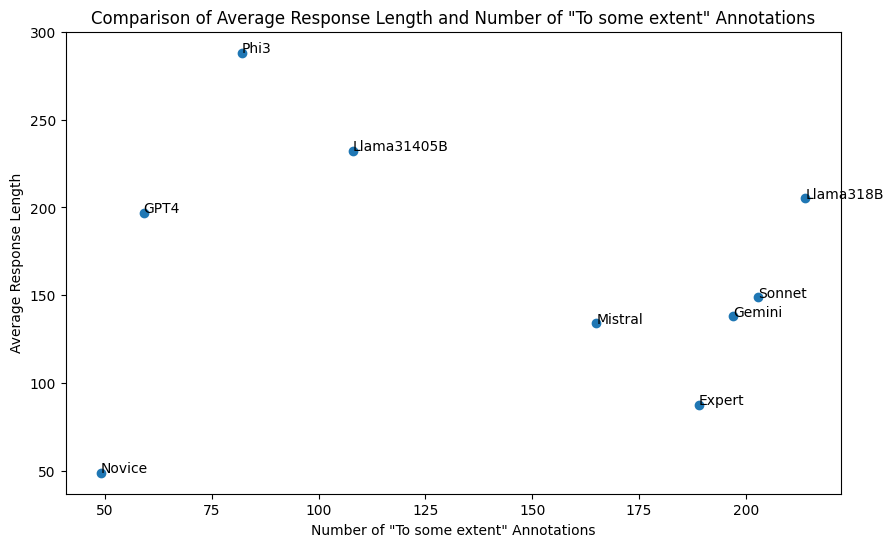

In [ ]:
# comparison of average response length and the total number of to some extent value for the 4 annotation for each tutor
# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(comparison_df['To some extent'], comparison_df['Average Response Length'])
plt.xlabel('Number of "To some extent" Annotations')
plt.ylabel('Average Response Length')
plt.title('Comparison of Average Response Length and Number of "To some extent" Annotations')
for i, txt in enumerate(comparison_df.index):
    plt.annotate(txt, (comparison_df['To some extent'][i], comparison_df['Average Response Length'][i]))
plt.show()

Top 5 positive cross-task correlations:
LOC_Yes and GUID_Yes: 0.74
GUID_Yes and LOC_Yes: 0.74
LOC_Yes and ID_Yes: 0.70
ID_Yes and LOC_Yes: 0.70
LOC_No and ID_No: 0.66

Top 5 negative cross-task correlations:
LOC_No and GUID_Yes: -0.54
GUID_Yes and LOC_No: -0.54
ID_Yes and LOC_No: -0.50
LOC_No and ID_Yes: -0.50
LOC_Yes and ID_No: -0.46


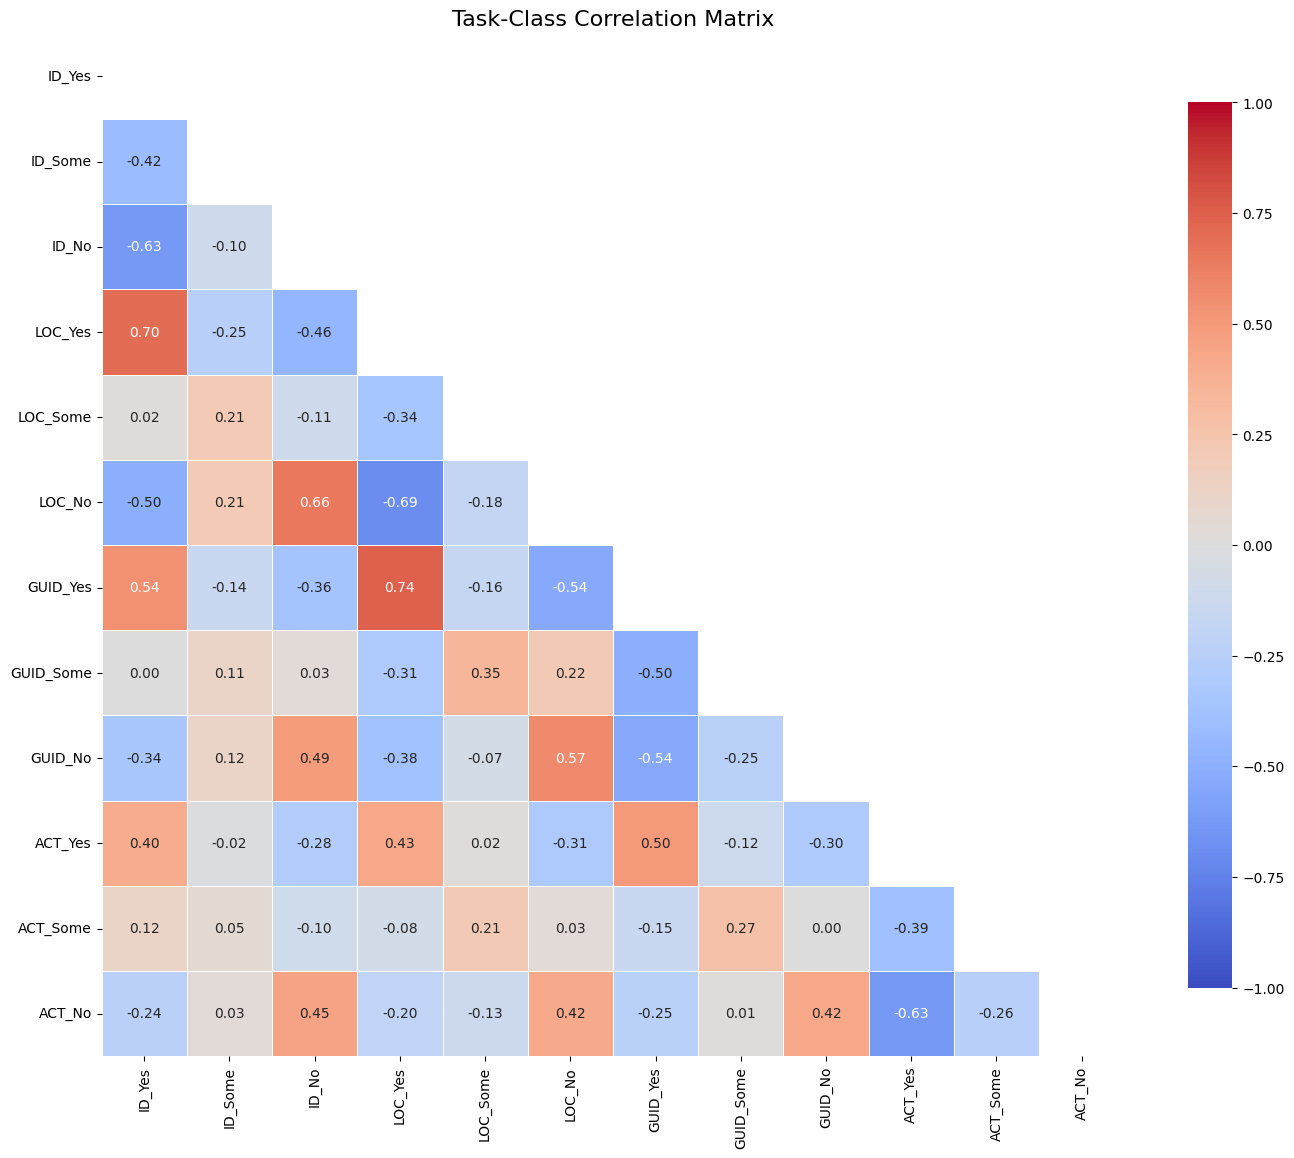

In [ ]:
def create_task_class_correlation_matrix(df, label_cols):
    """
    Creates a correlation matrix showing relationships between tasks and classes
    for exploratory data analysis.

    Args:
        df: DataFrame containing the raw data with annotation columns
        label_cols: List of column names for the 4 tasks

    Returns:
        Correlation figure and DataFrame
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Create one-hot encoded columns for each task-class combination
    one_hot_df = pd.DataFrame()

    task_short_names = ['ID', 'LOC', 'GUID', 'ACT']  # Shorter names for readability
    class_names = ['Yes', 'Some', 'No']

    # Map text labels to numeric for one-hot encoding
    label_map = {"Yes": 0, "To some extent": 1, "No": 2}

    # One-hot encode each class for each task
    for i, col in enumerate(label_cols):
        task_name = task_short_names[i]
        # Convert text labels to numeric if they're not already
        if df[col].dtype == object:
            df[f"{col}_numeric"] = df[col].map(label_map)
            task_col = f"{col}_numeric"
        else:
            task_col = col

        for j, cls in enumerate(class_names):
            one_hot_df[f"{task_name}_{cls}"] = (df[task_col] == j).astype(int)

    # Calculate correlation matrix
    corr = one_hot_df.corr()

    # Plot correlation matrix
    plt.figure(figsize=(14, 12))

    # Create mask for upper triangle to avoid redundancy
    mask = np.zeros_like(corr, dtype=bool)
    mask[np.triu_indices_from(mask)] = True

    # Plot heatmap
    sns.heatmap(
        corr,
        mask=mask,
        cmap='coolwarm',
        vmin=-1, vmax=1,
        center=0,
        square=True,
        linewidths=0.5,
        annot=True,
        fmt='.2f',
        cbar_kws={"shrink": 0.8}
    )

    plt.title('Task-Class Correlation Matrix', fontsize=16)
    plt.tight_layout()

    # Create a filtered version of the correlation matrix for finding top correlations
    # (excluding correlations within the same task)
    filtered_corr = corr.copy()
    for task in task_short_names:
        # Create a mask for all combinations within the same task
        same_task_mask = np.zeros_like(filtered_corr, dtype=bool)
        for i, idx in enumerate(filtered_corr.index):
            for j, col in enumerate(filtered_corr.columns):
                if idx.startswith(task) and col.startswith(task):
                    same_task_mask[i, j] = True

        # Set all within-task correlations to NaN
        filtered_corr.values[same_task_mask] = np.nan

    # Print the strongest cross-task relationships
    print("Top 5 positive cross-task correlations:")
    top_pos = filtered_corr.unstack().dropna().sort_values(ascending=False).head(5)
    for idx, val in top_pos.items():
        print(f"{idx[0]} and {idx[1]}: {val:.2f}")

    print("\nTop 5 negative cross-task correlations:")
    top_neg = filtered_corr.unstack().dropna().sort_values().head(5)
    for idx, val in top_neg.items():
        print(f"{idx[0]} and {idx[1]}: {val:.2f}")

    return plt.gcf(), corr, one_hot_df


# How to use for EDA:
label_cols = [
    'annotation_Mistake_Identification',
    'annotation_Mistake_Location',
    'annotation_Providing_Guidance',
    'annotation_Actionability'
]

# Run the correlation analysis
correlation_fig, correlation_matrix, one_hot_data = create_task_class_correlation_matrix(df, label_cols)




# Save the correlation matrix for further analysis
correlation_matrix.to_csv('eda_task_class_correlation.csv')


## DATA PREPARATION


In [ ]:
import pandas as pd
import numpy as np
from transformers import AutoTokenizer

# Load the tokenizer for accurate token counting
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def split_conversation_by_speaker(conversation_history):
    """
    Splits a conversation history into tutor and student parts.
    """
    if not isinstance(conversation_history, str):
        conversation_history = ""
    lines = conversation_history.split('\n')
    tutor_text, student_text = [], []
    current_speaker = None

    for line in lines:
        line = line.strip()
        if not line:
            continue

        if line.startswith("Tutor:"):
            current_speaker = "tutor"
            content = line[len("Tutor:"):].strip()
            if content:
                tutor_text.append(content)
        elif line.startswith("Student:"):
            current_speaker = "student"
            content = line[len("Student:"):].strip()
            if content:
                student_text.append(content)
        else:
            if current_speaker == "tutor":
                tutor_text.append(line)
            elif current_speaker == "student":
                student_text.append(line)

    return " ".join(tutor_text), " ".join(student_text)


def analyze_speaker_history_response_lengths(df):
    """
    Analyzes word and token lengths for:
      - tutor text
      - student text
      - response text
      - full conversation history
      - history + response
    Returns a stats dict with averages and maxima.
    """
    # Initialize lists
    tutor_words, student_words, response_words, history_words, hist_resp_words = [], [], [], [], []
    tutor_tokens, student_tokens, response_tokens, history_tokens, hist_resp_tokens = [], [], [], [], []

    for _, row in df.iterrows():
        # Safely handle missing or non-string fields
        conv = row.get('conversation_history', np.nan)
        if not isinstance(conv, str) or pd.isna(conv):
            conv = ""
        resp = row.get('response', np.nan)
        if not isinstance(resp, str) or pd.isna(resp):
            resp = ""

        tutor_text, student_text = split_conversation_by_speaker(conv)
        history_response = f"{conv} {resp}".strip()

        # Word counts
        tutor_words.append(len(tutor_text.split()))
        student_words.append(len(student_text.split()))
        response_words.append(len(resp.split()))
        history_words.append(len(conv.split()))
        hist_resp_words.append(len(history_response.split()))

        # Token counts
        tutor_tokens.append(len(tokenizer.encode(tutor_text)))
        student_tokens.append(len(tokenizer.encode(student_text)))
        response_tokens.append(len(tokenizer.encode(resp)))
        history_tokens.append(len(tokenizer.encode(conv)))
        hist_resp_tokens.append(len(tokenizer.encode(history_response)))

    stats = {
        'word_stats': {
            'tutor': {'average': np.mean(tutor_words), 'max': np.max(tutor_words)},
            'student': {'average': np.mean(student_words), 'max': np.max(student_words)},
            'response': {'average': np.mean(response_words), 'max': np.max(response_words)},
            'history': {'average': np.mean(history_words), 'max': np.max(history_words)},
            'history_response': {'average': np.mean(hist_resp_words), 'max': np.max(hist_resp_words)}
        },
        'token_stats': {
            'tutor': {'average': np.mean(tutor_tokens), 'max': np.max(tutor_tokens)},
            'student': {'average': np.mean(student_tokens), 'max': np.max(student_tokens)},
            'response': {'average': np.mean(response_tokens), 'max': np.max(response_tokens)},
            'history': {'average': np.mean(history_tokens), 'max': np.max(history_tokens)},
            'history_response': {'average': np.mean(hist_resp_tokens), 'max': np.max(hist_resp_tokens)}
        }
    }
    return stats


def add_length_columns(df):
    """
    Adds columns for:
      - tutor_text, student_text, response_text
      - tutor_word_count, student_word_count, response_word_count
      - history_word_count, history_response_word_count
      - tutor_token_count, student_token_count, response_token_count
      - history_token_count, history_response_token_count
    """
    tutor_texts, student_texts, response_texts = [], [], []
    t_words, s_words, r_words, h_words, hr_words = [], [], [], [], []
    t_tokens, s_tokens, r_tokens, h_tokens, hr_tokens = [], [], [], [], []

    for _, row in df.iterrows():
        conv = row.get('conversation_history', np.nan)
        if not isinstance(conv, str) or pd.isna(conv):
            conv = ""
        resp = row.get('response', np.nan)
        if not isinstance(resp, str) or pd.isna(resp):
            resp = ""

        tutor_text, student_text = split_conversation_by_speaker(conv)
        history_response = f"{conv} {resp}".strip()

        # Store texts
        tutor_texts.append(tutor_text)
        student_texts.append(student_text)
        response_texts.append(resp)

        # Word counts
        t_words.append(len(tutor_text.split()))
        s_words.append(len(student_text.split()))
        r_words.append(len(resp.split()))
        h_words.append(len(conv.split()))
        hr_words.append(len(history_response.split()))

        # Token counts
        t_tokens.append(len(tokenizer.encode(tutor_text)))
        s_tokens.append(len(tokenizer.encode(student_text)))
        r_tokens.append(len(tokenizer.encode(resp)))
        h_tokens.append(len(tokenizer.encode(conv)))
        hr_tokens.append(len(tokenizer.encode(history_response)))

    df['tutor_text'] = tutor_texts
    df['student_text'] = student_texts
    df['response_text'] = response_texts
    df['tutor_word_count'] = t_words
    df['student_word_count'] = s_words
    df['response_word_count'] = r_words
    df['history_word_count'] = h_words
    df['history_response_word_count'] = hr_words
    df['tutor_token_count'] = t_tokens
    df['student_token_count'] = s_tokens
    df['response_token_count'] = r_tokens
    df['history_token_count'] = h_tokens
    df['history_response_token_count'] = hr_tokens

    return df

# Example usage
stats = analyze_speaker_history_response_lengths(df)

print("=== Word Statistics ===")
for key, vals in stats['word_stats'].items():
    print(f"{key.capitalize():16} - Avg: {vals['average']:.2f}, Max: {vals['max']}")

print("\n=== Token Statistics ===")
for key, vals in stats['token_stats'].items():
    print(f"{key.capitalize():16} - Avg: {vals['average']:.2f}, Max: {vals['max']}")

# Add columns to DataFrame
df = add_length_columns(df)


Token indices sequence length is longer than the specified maximum sequence length for this model (518 > 512). Running this sequence through the model will result in indexing errors


=== Word Statistics ===
Tutor            - Avg: 75.53, Max: 213
Student          - Avg: 116.21, Max: 257
Response         - Avg: 29.66, Max: 721
History          - Avg: 197.27, Max: 388
History_response - Avg: 226.92, Max: 1021

=== Token Statistics ===
Tutor            - Avg: 95.99, Max: 258
Student          - Avg: 149.64, Max: 344
Response         - Avg: 40.64, Max: 954
History          - Avg: 254.67, Max: 512
History_response - Avg: 293.32, Max: 1386


In [ ]:
def extract_question(conversation):
    lines = conversation.strip().split('\xa0')  # Split on \xa0 which behaves like newlines in your data
    question_parts = []
    collecting = False

    for line in lines:
        line = line.strip()
        if line.startswith("Tutor:"):
            content = line[len("Tutor:"):].strip()
            if "The question is:" in content:
                # Start collecting right after "The question is:"
                question_start = content.split("The question is:", 1)[-1].strip()
                question_parts.append(question_start)
                collecting = True
            elif collecting:
                question_parts.append(content)
        elif line.startswith("Student:") and collecting:
            break
        elif collecting:
            question_parts.append(line)

    return " ".join(question_parts).strip()

df['question'] = df['conversation_history'].apply(extract_question)

In [ ]:
df["tutor_text"] = df["tutor_text"].apply(lambda x: x.replace('\xa0', ' '))
df["student_text"] = df["student_text"].apply(lambda x: x.replace('\xa0', ' '))
df["conversation_history"] = df["conversation_history"].apply(lambda x: x.replace('\xa0', ' '))


In [ ]:
first_row = str(df['response'][0]) + '[SEP]' + str(df['student_text'][0]) + '[SEP]' + str(df['question'][0])
first_row

'Now that we know the cost of 1 pound of meat is $7.00, we can use this information to find the correct total cost for the meat and cheese needed for the muffaletta sandwiches.[SEP]To serve 20 people, Tyson needs to make 20/4 = 5 sandwiches. Each sandwich requires 1+1 = 2 pounds of meat and cheese. For 5 sandwiches, he needs a total of 2 x 5 = 10 pounds of meat and cheese. The cost of 10 pounds of meat is 10 x $7.00 = $70. The cost of 10 pounds of cheese is 10 x $3.00 = $30. The total cost of meat and cheese is $70 + $30 = $100. 100 Each sandwich requires 1 pound of meat and 1 pound of cheese. The cost of 1 pound of meat is $7.00.[SEP]Tyson decided to make muffaletta sandwiches for the big game.  Each sandwich required 1 pound each of meat and cheese and would serve 4 people.  There would be 20 people in total watching the game.  The meat cost $7.00 per pound and the cheese cost $3.00 per pound.  How much money would he spend on the meat and cheese to make enough sandwiches to serve 20